# Phase 3: PBMC4k singlet cluster annotation

This notebook loads the singlet-only PBMC4k clustering produced by `03_remove_doublets_recluster.ipynb`, reviews data-derived markers and the exact PBMC3k reference-marker panel, and provides one clearly marked table for human annotation.

The notebook will not apply or save cell-type labels while any cluster remains `REVIEW_REQUIRED`. Marker-based labels are working annotations rather than independent experimental ground truth.

## Annotation workflow

For every Leiden cluster:

1. Review cluster size and UMAP position.
2. Review at least several concordant data-derived marker genes.
3. Compare expression with the unchanged PBMC3k marker programs.
4. Check for mitochondrial, ribosomal, stress, or conflicting-lineage signals.
5. Review the ribosomal-exclusion sensitivity analysis in Section 6.
6. Edit the decision table in Section 8.
7. Use `high`, `moderate`, or `low` confidence; use a broad or `Ambiguous` label when necessary.

Do not identify a cluster from one gene alone.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display

N_EXPECTED_CLUSTERS = 10
N_MARKERS_TO_DISPLAY = 15
MIN_LOG2_FOLD_CHANGE = 0.5
MAX_ADJUSTED_P_VALUE = 0.05
MIN_FRACTION_EXPRESSING = 0.25
RANK_KEY = "rank_genes_groups_leiden_singlets"

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Load and validate the singlet-only clustered object

In [2]:
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend(
        (base, base / "PBMC4k", base / "26-the-backpropagators-analysis" / "PBMC4k")
    )

PROJECT = next(
    (
        path
        for path in candidates
        if (path / "data" / "processed" / "pbmc4k_phase2_singlets_clustered.h5ad").is_file()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run PBMC4k Notebook 03 first; expected "
        "PBMC4k/data/processed/pbmc4k_phase2_singlets_clustered.h5ad"
    )

INPUT = PROJECT / "data" / "processed" / "pbmc4k_phase2_singlets_clustered.h5ad"
OUTPUT = PROJECT / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad"
FIGURES = PROJECT / "results" / "figures"
TABLES = PROJECT / "results" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT)
requirements = {
    "Leiden clusters": "leiden" in adata.obs,
    "UMAP coordinates": "X_umap" in adata.obsm,
    "all-gene normalized expression": adata.raw is not None,
    "no predicted doublets": (
        "predicted_doublet" in adata.obs and not adata.obs["predicted_doublet"].astype(bool).any()
    ),
}
display(pd.Series(requirements, name="available").to_frame())
if not all(requirements.values()):
    raise ValueError("The singlet-only Phase 2b object is incomplete.")

cluster_names = list(adata.obs["leiden"].cat.categories)
if len(cluster_names) != N_EXPECTED_CLUSTERS:
    raise ValueError(
        f"Expected {N_EXPECTED_CLUSTERS} singlet clusters, observed {len(cluster_names)}. "
        "Update and re-review the annotation scaffold before continuing."
    )
print(adata)
print("Input:", INPUT)

,available
Leiden clusters,True
UMAP coordinates,True
all-gene normalized expression,True
no predicted doublets,True


AnnData object with n_obs × n_vars = 4131 × 2000
    obs: 'dataset', 'original_barcode', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc', 'doublet_score', 'predicted_doublet', 'original_leiden', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_pbmc4k_std', 'mean', 'std'
    uns: 'dendrogram_leiden', 'doublet_filtering', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'original_leiden_colors', 'pca', 'phase2b_reclustering', 'rank_genes_groups_leiden_singlets', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_normalized'
    obsp: 'connectivities', 'distances'
Input: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/processed/pbmc4k_phase2_singlets_clustered.h5ad


## 2. Cluster overview

,cells,percent
leiden,,
0,188,4.6%
1,735,17.8%
2,440,10.7%
3,1075,26.0%
4,588,14.2%
5,34,0.8%
6,592,14.3%
7,181,4.4%
8,192,4.6%


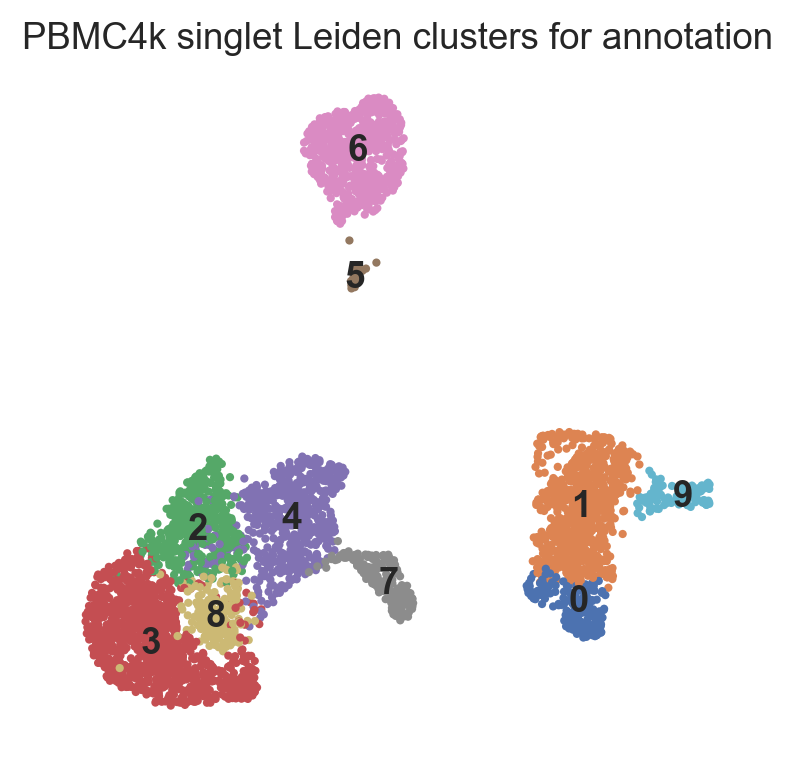

In [3]:
cluster_sizes = adata.obs["leiden"].value_counts().sort_index().rename("cells").to_frame()
cluster_sizes["percent"] = 100 * cluster_sizes["cells"] / adata.n_obs
display(cluster_sizes.style.format({"percent": "{:.1f}%"}))

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="PBMC4k singlet Leiden clusters for annotation",
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase3_annotation_cluster_umap.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Data-derived marker evidence

The Wilcoxon ranking compares every cluster against the remaining cells using all normalized genes in `.raw`. The PBMC3k reporting thresholds are reused: adjusted p-value below 0.05, log2 fold change above 0.5, and expression in at least 25% of the cluster.

In [4]:
if RANK_KEY not in adata.uns:
    sc.tl.rank_genes_groups(
        adata,
        groupby="leiden",
        method="wilcoxon",
        reference="rest",
        use_raw=True,
        pts=True,
        corr_method="benjamini-hochberg",
        key_added=RANK_KEY,
    )

all_markers = sc.get.rank_genes_groups_df(adata, group=None, key=RANK_KEY)
all_markers["group"] = all_markers["group"].astype(str)
filtered_markers = all_markers.loc[
    (all_markers["pvals_adj"] < MAX_ADJUSTED_P_VALUE)
    & (all_markers["logfoldchanges"] > MIN_LOG2_FOLD_CHANGE)
    & (all_markers["pct_nz_group"] >= MIN_FRACTION_EXPRESSING)
].copy()
filtered_markers["expression_fraction_gap"] = (
    filtered_markers["pct_nz_group"] - filtered_markers["pct_nz_reference"]
)
filtered_markers = filtered_markers.sort_values(["group", "scores"], ascending=[True, False])

all_markers.to_csv(TABLES / "pbmc4k_phase3_all_marker_statistics.csv", index=False)
filtered_markers.to_csv(TABLES / "pbmc4k_phase3_filtered_markers.csv", index=False)
display(filtered_markers.groupby("group", observed=True).head(10))

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,expression_fraction_gap
0,0,RP11-1143G9.4,20.228201,4.924306,5.528368e-91,9.044964e-87,0.978723,0.256404,0.722320
1,0,S100A8,20.157127,5.362037,2.330227e-90,1.906242e-86,1.000000,0.583059,0.416941
2,0,LYZ,19.412848,5.131172,6.010241e-84,3.277785e-80,0.994681,0.608420,0.386261
3,0,FTL,19.285191,2.713250,7.152518e-83,2.925559e-79,1.000000,0.995181,0.004819
4,0,S100A9,19.194244,4.919293,4.134462e-82,1.352879e-78,0.989362,0.663454,0.325907
...,...,...,...,...,...,...,...,...,...
147254,9,PSAP,16.149195,3.502439,1.150555e-58,3.137373e-55,1.000000,0.578882,0.421118
147255,9,FTH1,16.118090,2.473231,1.904041e-58,4.450288e-55,1.000000,0.991056,0.008944
147256,9,SERPINA1,16.047302,4.277987,5.970403e-58,1.221022e-54,1.000000,0.232298,0.767702
147257,9,FCER1G,15.923587,4.126081,4.347245e-57,7.902809e-54,1.000000,0.392298,0.607702


,top_filtered_markers,cells
group,,
0,"RP11-1143G9.4, S100A8, LYZ, FTL, S100A9, FTH1,...",188
1,"LYZ, CST3, S100A9, FCN1, GPX1, S100A8, S100A6,...",735
2,"IL32, LTB, IL7R, TRAC, LDHB, ITGB1, CD2, CD3D,...",440
3,"RPL32, RPS6, RPL21, RPL31, RPS14, RPL34, RPS3A...",1075
4,"CCL5, IL32, HLA-B, NKG7, B2M, HLA-C, GZMA, CST...",588
5,"SEC61B, LILRA4, IRF7, PLD4, JCHAIN, IRF8, ITM2...",34
6,"CD79A, CD74, CD79B, MS4A1, CD37, HLA-DPA1, HLA...",592
7,"NKG7, GNLY, CTSW, HOPX, KLRF1, PRF1, KLRD1, GZ...",181
8,"RPS14, RPS6, RPS12, RPL32, RPS27, MALAT1, RPL3...",192


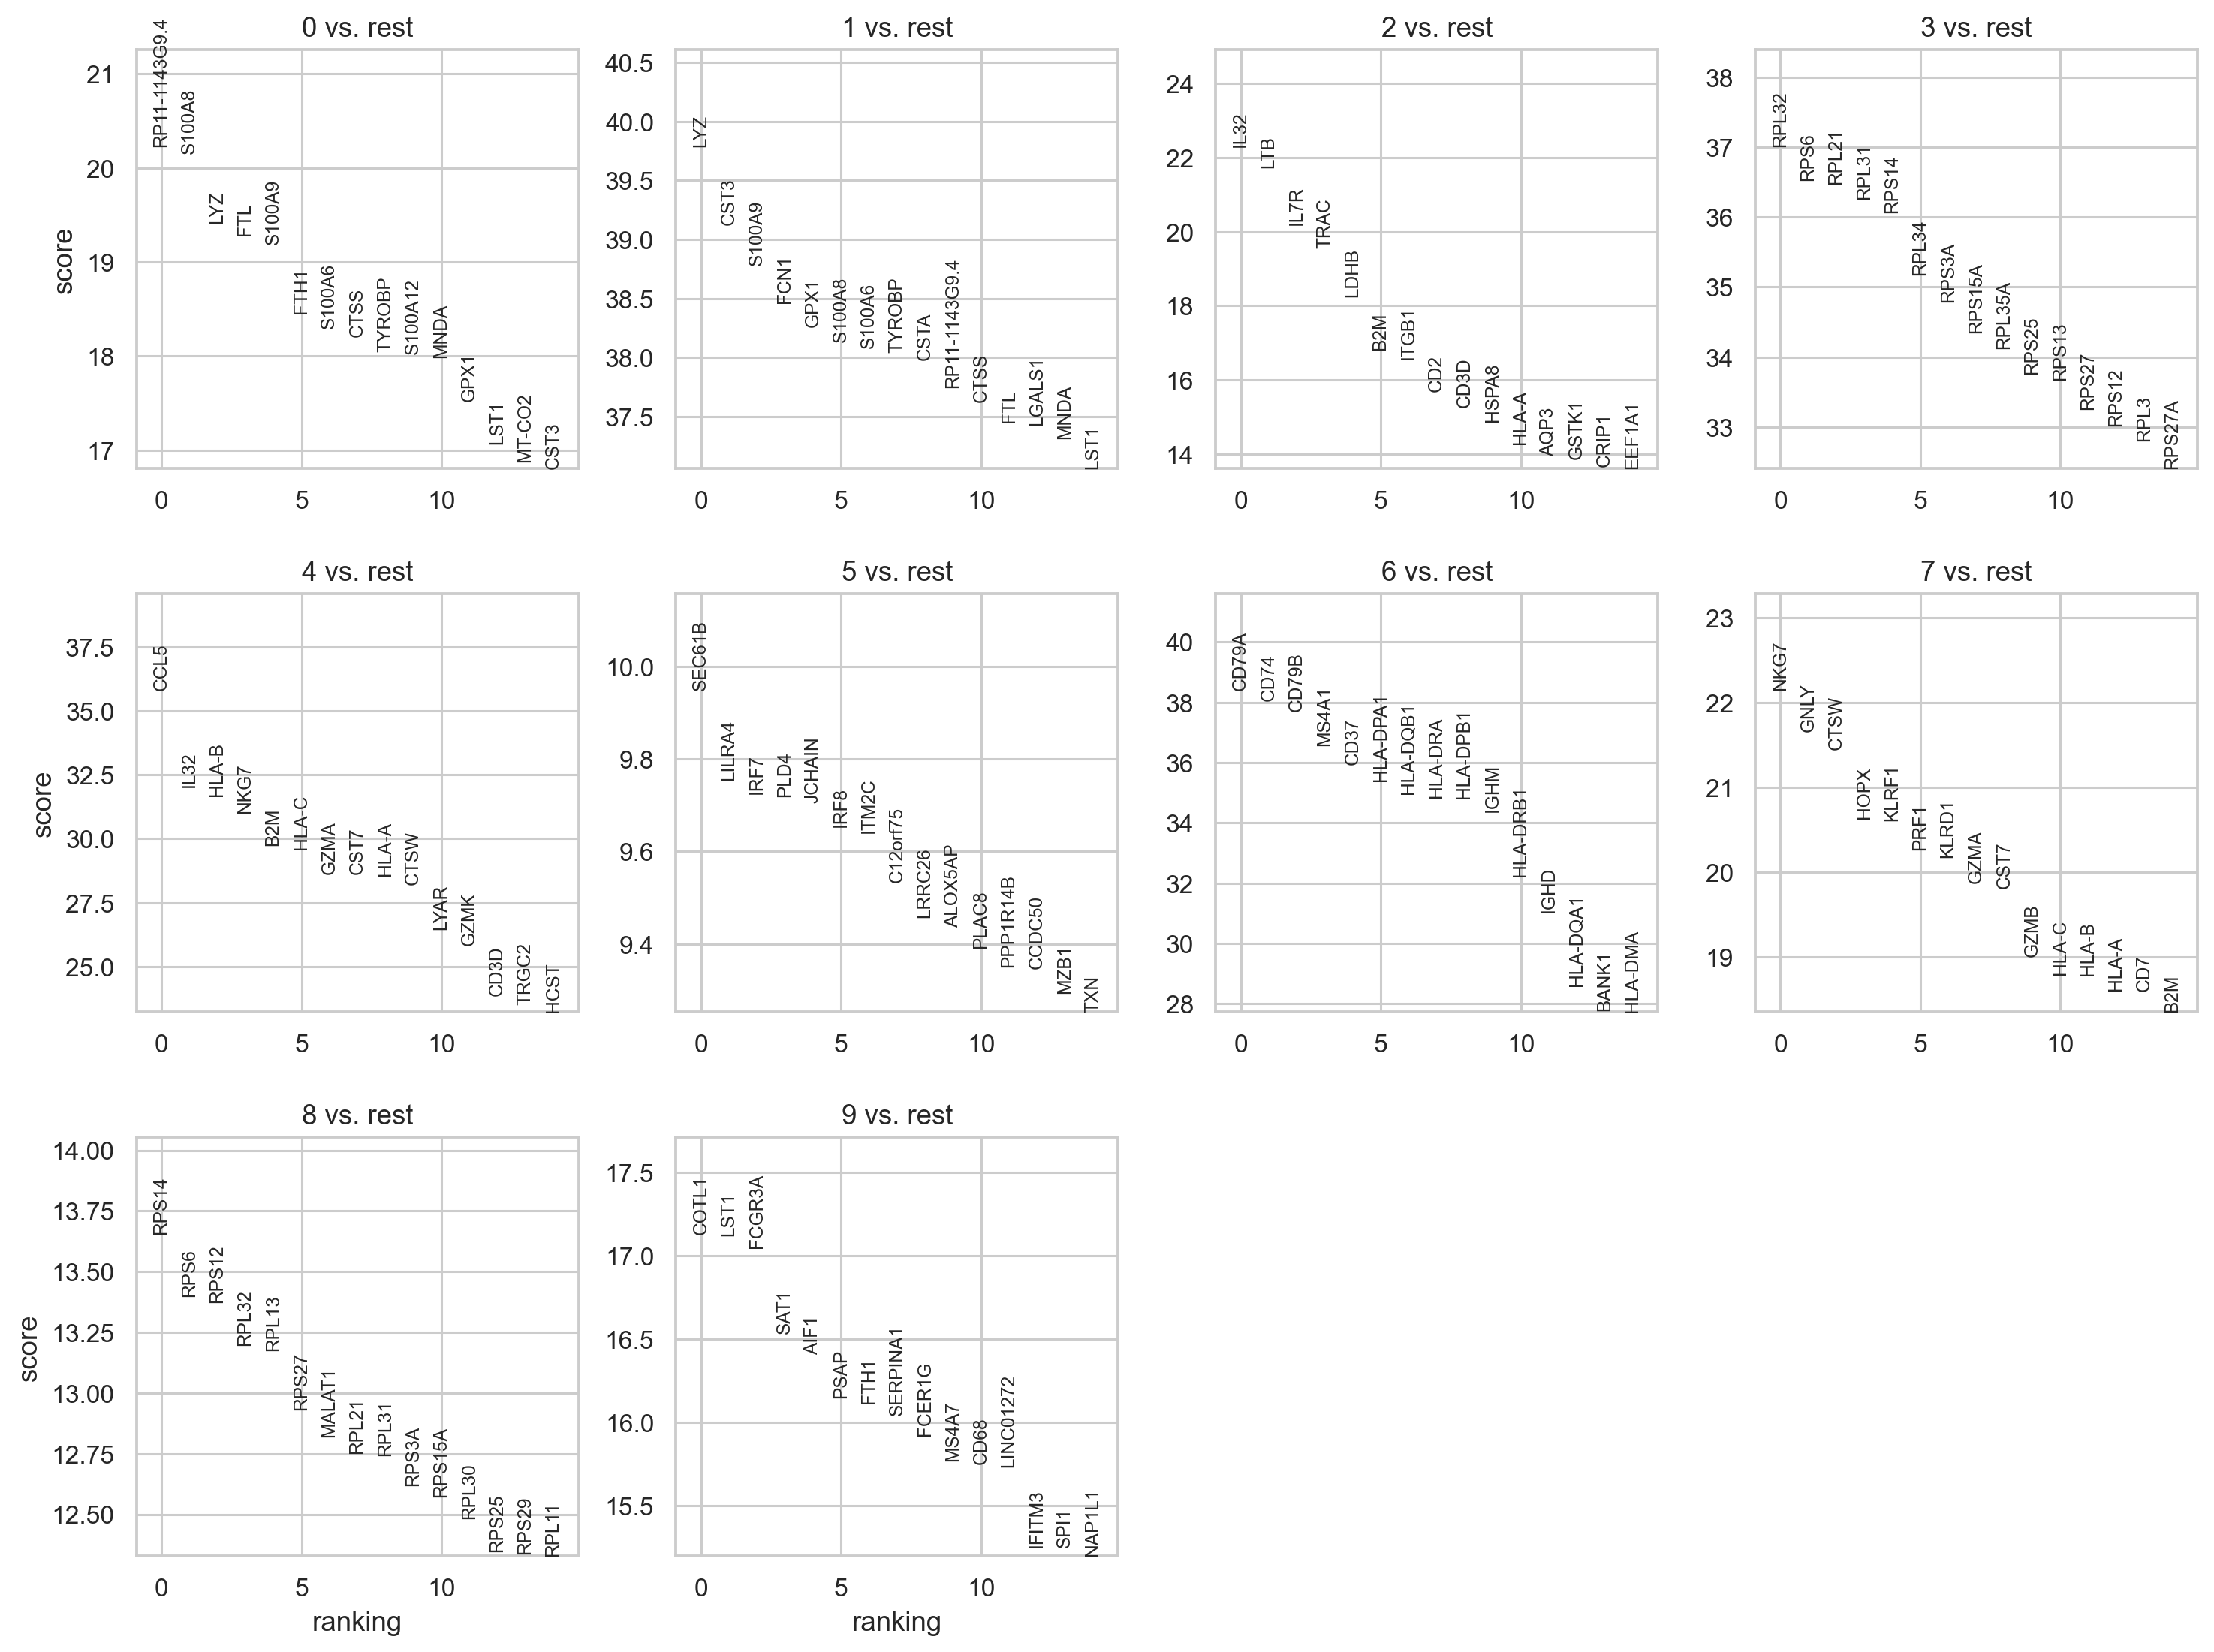

In [5]:
cluster_marker_summary = (
    filtered_markers.groupby("group", observed=True)["names"]
    .apply(lambda genes: ", ".join(genes.head(N_MARKERS_TO_DISPLAY)))
    .rename("top_filtered_markers")
    .to_frame()
    .reindex([str(cluster) for cluster in cluster_names])
)
cluster_marker_summary["cells"] = [
    int(cluster_sizes.loc[cluster, "cells"]) for cluster in cluster_names
]
cluster_marker_summary.to_csv(TABLES / "pbmc4k_phase3_marker_summary.csv")
display(cluster_marker_summary)

sc.pl.rank_genes_groups(
    adata,
    key=RANK_KEY,
    n_genes=N_MARKERS_TO_DISPLAY,
    sharey=False,
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase3_ranked_markers.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Exact PBMC3k reference-marker panel

This panel is copied unchanged for cross-dataset consistency. It does **not** contain a plasmacytoid dendritic-cell program. A pDC candidate must therefore also be evaluated from data-derived markers such as `LILRA4`, `JCHAIN`, `GZMB`, `IRF7`, and `PLD4`.

,markers absent from PBMC4k
Naive/helper T,[]
Cytotoxic T,[]
NK,[]
B,[]
CD14 monocyte,[]
FCGR3A monocyte,[]
Dendritic,[]
Platelet,[]


categories: 0, 1, 2, etc.
var_group_labels: Naive/helper T, Cytotoxic T, NK, etc.


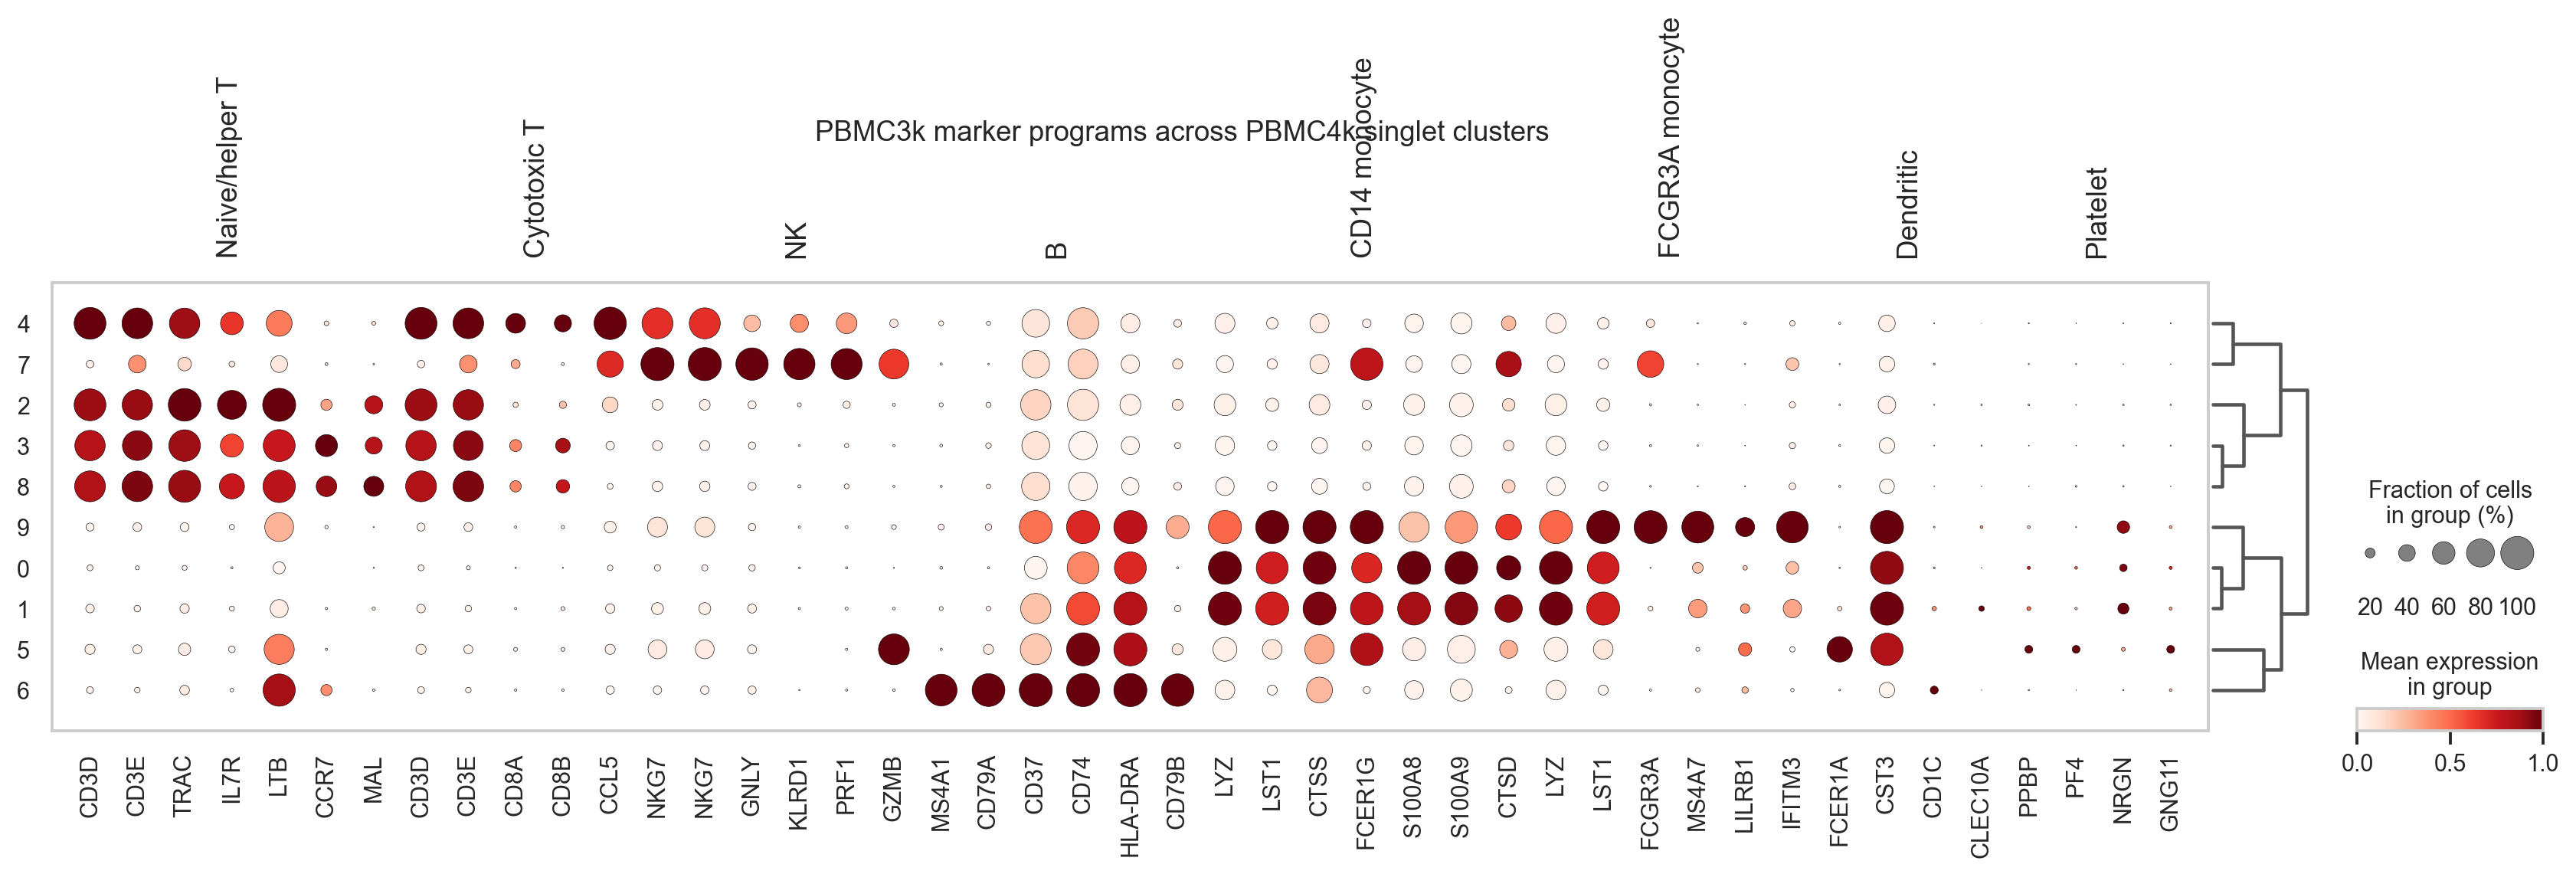

In [6]:
pbmc_marker_panel = {
    "Naive/helper T": ["CD3D", "CD3E", "TRAC", "IL7R", "LTB", "CCR7", "MAL"],
    "Cytotoxic T": ["CD3D", "CD3E", "CD8A", "CD8B", "CCL5", "NKG7"],
    "NK": ["NKG7", "GNLY", "KLRD1", "PRF1", "GZMB"],
    "B": ["MS4A1", "CD79A", "CD37", "CD74", "HLA-DRA", "CD79B"],
    "CD14 monocyte": ["LYZ", "LST1", "CTSS", "FCER1G", "S100A8", "S100A9", "CTSD"],
    "FCGR3A monocyte": ["LYZ", "LST1", "FCGR3A", "MS4A7", "LILRB1", "IFITM3"],
    "Dendritic": ["FCER1A", "CST3", "CD1C", "CLEC10A"],
    "Platelet": ["PPBP", "PF4", "NRGN", "GNG11"],
}

raw_genes = set(adata.raw.var_names)
missing_reference_genes = {
    cell_type: [gene for gene in genes if gene not in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: [gene for gene in genes if gene in raw_genes]
    for cell_type, genes in pbmc_marker_panel.items()
}
available_pbmc_markers = {
    cell_type: genes for cell_type, genes in available_pbmc_markers.items() if genes
}
display(pd.Series(missing_reference_genes, name="markers absent from PBMC4k").to_frame())

sc.pl.dotplot(
    adata,
    available_pbmc_markers,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    dendrogram=True,
    title="PBMC3k marker programs across PBMC4k singlet clusters",
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase3_reference_marker_dotplot.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Reference-marker overlap

Overlap is supporting evidence only. The highest score does not automatically determine a label, especially for related T-cell states, dendritic populations absent from the panel, or broad myeloid clusters.

,0,1,2,3,4,5,6,7,8,9
Naive/helper T,0.00,0.00,0.86,0.71,0.57,0.00,0.14,0.00,1.00,0.00
Cytotoxic T,0.00,0.00,0.33,0.33,1.00,0.00,0.00,0.33,0.33,0.00
NK,0.00,0.00,0.00,0.00,0.80,0.20,0.00,1.00,0.00,0.00
B,0.17,0.17,0.00,0.00,0.00,0.17,1.00,0.00,0.00,0.00
CD14 monocyte,1.00,1.00,0.00,0.00,0.00,0.14,0.00,0.29,0.00,0.43
FCGR3A monocyte,0.33,0.33,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.67
Dendritic,0.25,0.25,0.00,0.00,0.00,0.25,0.00,0.00,0.00,0.25
Platelet,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


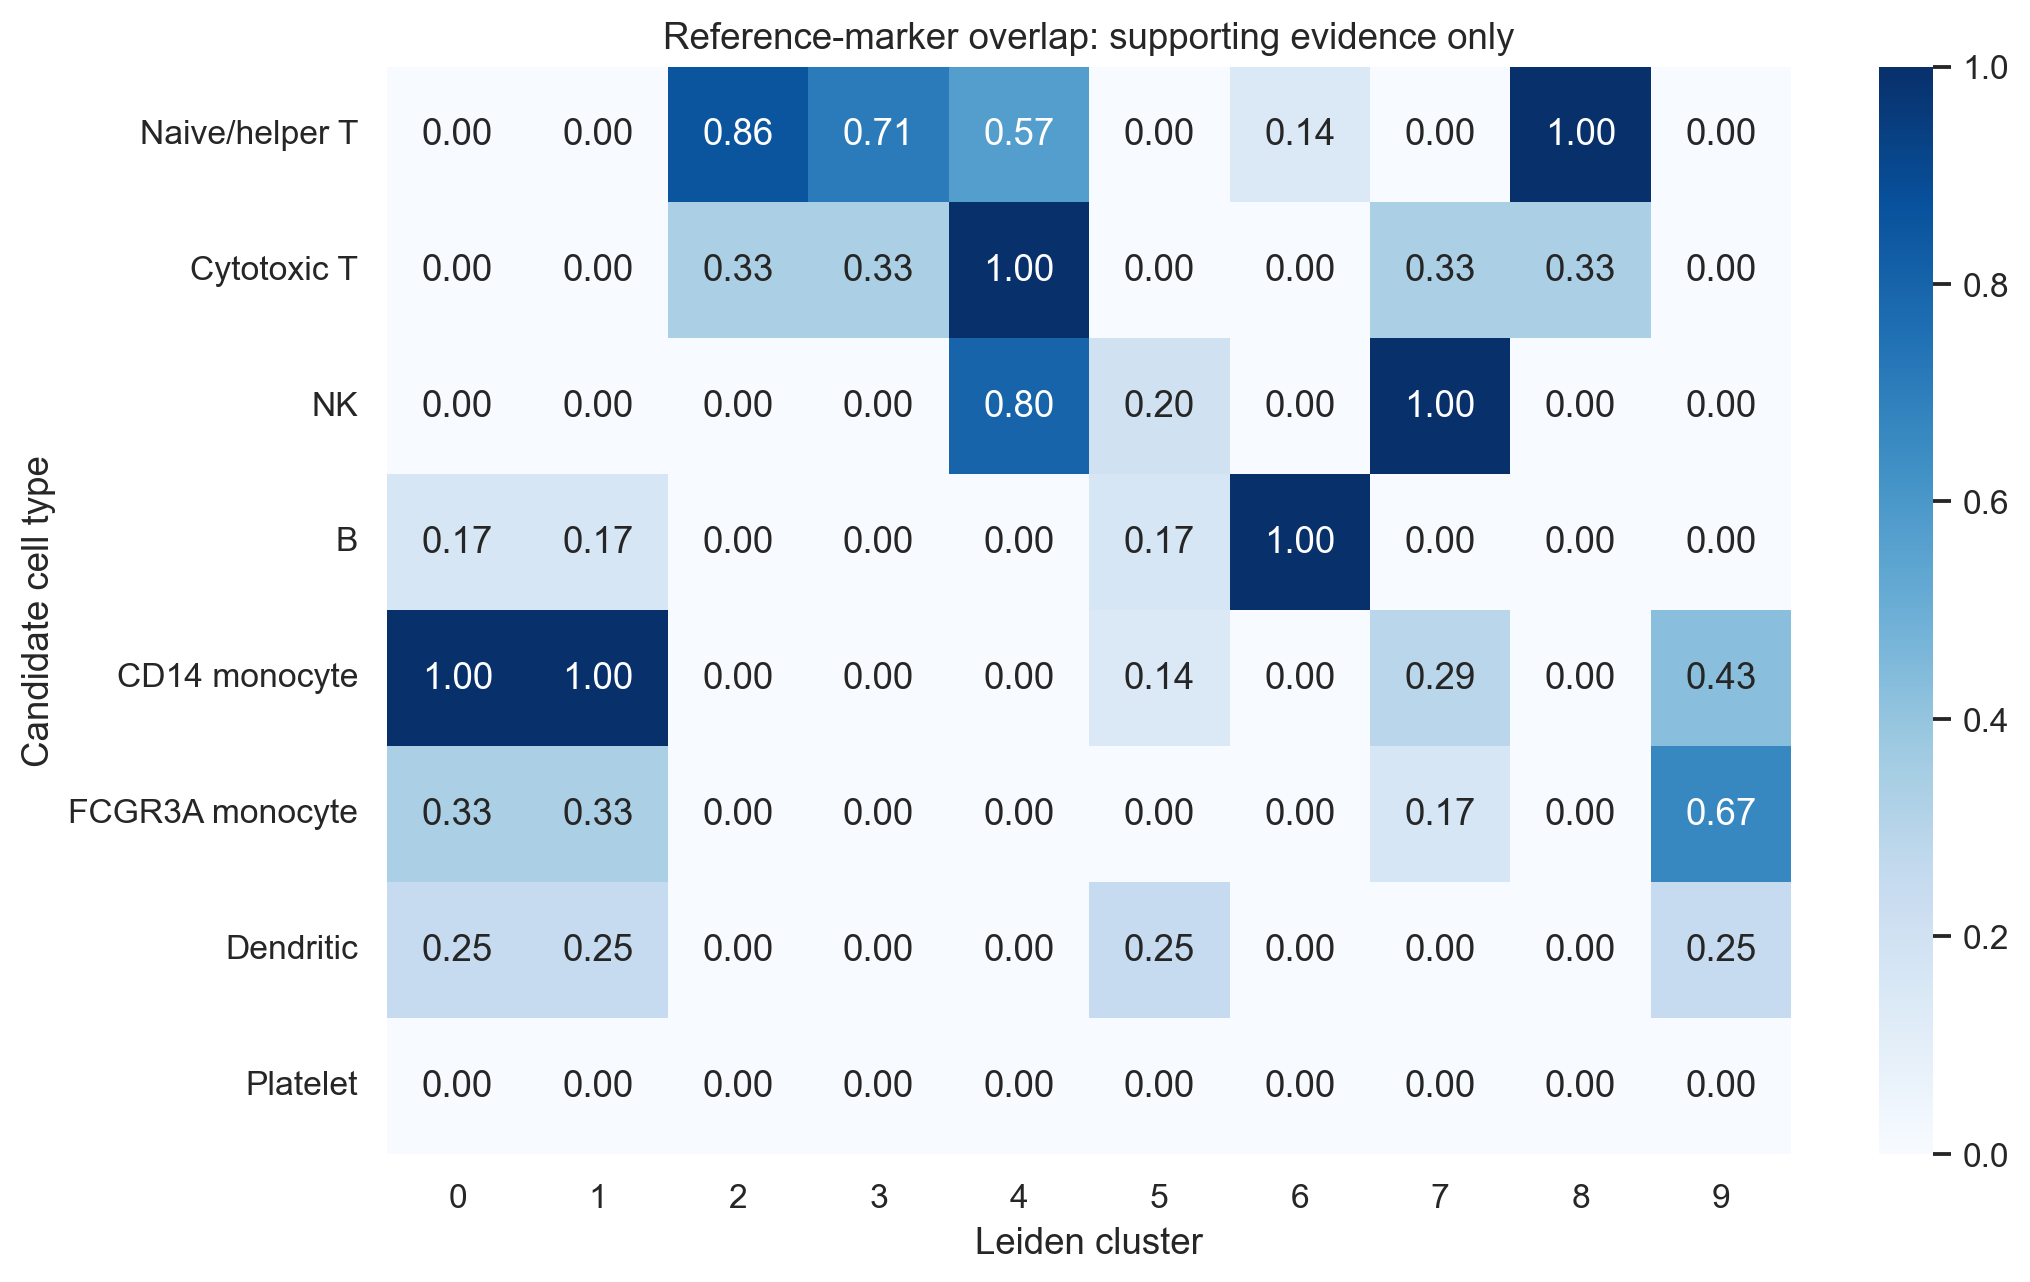

,best_reference_program,best_reference_overlap
0,CD14 monocyte,1.00
1,CD14 monocyte,1.00
2,Naive/helper T,0.86
3,Naive/helper T,0.71
4,Cytotoxic T,1.00
5,Dendritic,0.25
6,B,1.00
7,NK,1.00
8,Naive/helper T,1.00
9,FCGR3A monocyte,0.67


In [7]:
marker_overlap = sc.tl.marker_gene_overlap(
    adata,
    reference_markers=available_pbmc_markers,
    key=RANK_KEY,
    method="overlap_count",
    normalize="reference",
    top_n_markers=100,
    inplace=False,
)
display(marker_overlap.style.background_gradient(cmap="Blues", axis=None).format("{:.2f}"))

plt.figure(figsize=(10, 6))
sns.heatmap(marker_overlap, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Reference-marker overlap: supporting evidence only")
plt.xlabel("Leiden cluster")
plt.ylabel("Candidate cell type")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase3_marker_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

best_reference_program = marker_overlap.idxmax(axis=0).rename("best_reference_program")
best_reference_score = marker_overlap.max(axis=0).rename("best_reference_overlap")
reference_suggestions = pd.concat([best_reference_program, best_reference_score], axis=1)
reference_suggestions.index = reference_suggestions.index.astype(str)
reference_suggestions.to_csv(TABLES / "pbmc4k_phase3_reference_suggestions.csv")
display(reference_suggestions.style.format({"best_reference_overlap": "{:.2f}"}))

## 6. Ribosomal-exclusion sensitivity analysis

Clusters 3 and 8 have coherent T-cell markers but unusually strong ribosomal rankings. This sensitivity analysis reloads the normalized singlet object, removes `RPL`, `RPS`, and `MT-` genes from the existing 2,000 clustering features, and reruns scaling, PCA, 15-nearest-neighbor graph construction, UMAP, and Leiden resolution 0.5.

The analysis does not delete cells and does not replace the primary `adata.obs['leiden']` labels. It asks whether the original cluster-3 cells still form a distinct community when ribosomal and mitochondrial genes cannot drive PCA.

In [8]:
from sklearn.metrics import adjusted_rand_score

SENSITIVITY_RANDOM_STATE = 42
SENSITIVITY_N_PCS = 10
SENSITIVITY_N_NEIGHBORS = 15
SENSITIVITY_LEIDEN_RESOLUTION = 0.5

sensitivity = sc.read_h5ad(INPUT)
if "log_normalized" not in sensitivity.layers:
    raise ValueError("Expected normalized selected-gene expression in layers['log_normalized'].")

# Restore normalized expression because the saved main matrix is scaled.
sensitivity.X = sensitivity.layers["log_normalized"].copy()
gene_names_upper = sensitivity.var_names.str.upper()
excluded_feature_mask = gene_names_upper.str.startswith(("RPL", "RPS", "MT-"))
excluded_features = sensitivity.var_names[excluded_feature_mask].tolist()
sensitivity = sensitivity[:, ~excluded_feature_mask].copy()

sc.pp.scale(sensitivity, max_value=10)
n_pcs_available = min(50, sensitivity.n_obs - 1, sensitivity.n_vars - 1)
sc.tl.pca(
    sensitivity,
    n_comps=n_pcs_available,
    svd_solver="arpack",
    random_state=SENSITIVITY_RANDOM_STATE,
)
pcs_used_sensitivity = min(SENSITIVITY_N_PCS, sensitivity.obsm["X_pca"].shape[1])
sc.pp.neighbors(
    sensitivity,
    n_neighbors=SENSITIVITY_N_NEIGHBORS,
    n_pcs=pcs_used_sensitivity,
    method="umap",
    random_state=SENSITIVITY_RANDOM_STATE,
)
sc.tl.umap(sensitivity, random_state=SENSITIVITY_RANDOM_STATE)
sc.tl.leiden(
    sensitivity,
    resolution=SENSITIVITY_LEIDEN_RESOLUTION,
    key_added="leiden_no_ribo_mt",
    random_state=SENSITIVITY_RANDOM_STATE,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

primary_labels = adata.obs.loc[sensitivity.obs_names, "leiden"].astype(str)
sensitivity_labels = sensitivity.obs["leiden_no_ribo_mt"].astype(str)
sensitivity.obs["original_leiden"] = pd.Categorical(primary_labels)

sensitivity_summary = pd.Series(
    {
        "starting PCA features": adata.n_vars,
        "RPL/RPS/MT features excluded": len(excluded_features),
        "PCA features retained": sensitivity.n_vars,
        "primary clusters": primary_labels.nunique(),
        "no-ribosomal/MT clusters": sensitivity_labels.nunique(),
        "global adjusted Rand index": adjusted_rand_score(primary_labels, sensitivity_labels),
    },
    name="Ribosomal-exclusion sensitivity result",
)
display(sensitivity_summary.to_frame())

computing PCA


    with n_comps=50


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:02)


computing neighbors


...

computing UMAP


    finished (0:00:06)


running Leiden clustering


    finished (0:00:00)


,Ribosomal-exclusion sensitivity result
starting PCA features,2000.000000
RPL/RPS/MT features excluded,46.000000
PCA features retained,1954.000000
primary clusters,10.000000
no-ribosomal/MT clusters,10.000000
global adjusted Rand index,0.835753


no_ribo_mt_leiden,0,1,2,3,4,5,6,7,8,9
primary_leiden,,,,,,,,,,
0,188,0,0,0,0,0,0,0,0,0
1,732,0,0,0,0,0,0,0,0,3
2,0,430,4,0,0,3,0,0,3,0
3,0,28,930,0,0,2,0,110,5,0
4,0,47,0,0,0,528,1,3,9,0
5,0,0,0,33,1,0,0,0,0,0
6,0,0,0,0,592,0,0,0,0,0
7,0,0,0,0,0,5,176,0,0,0
8,0,6,6,0,0,0,0,1,179,0


,original_cells,dominant_no_ribo_mt_cluster,cells_in_dominant_destination,cohesion,destination_cluster_cells,exclusivity
original_cluster,,,,,,
3,1075,2,930,86.5%,940,98.9%
8,192,8,179,93.2%,196,91.3%


Clusters 3 and 8 share the same dominant no-ribosomal/MT destination: False


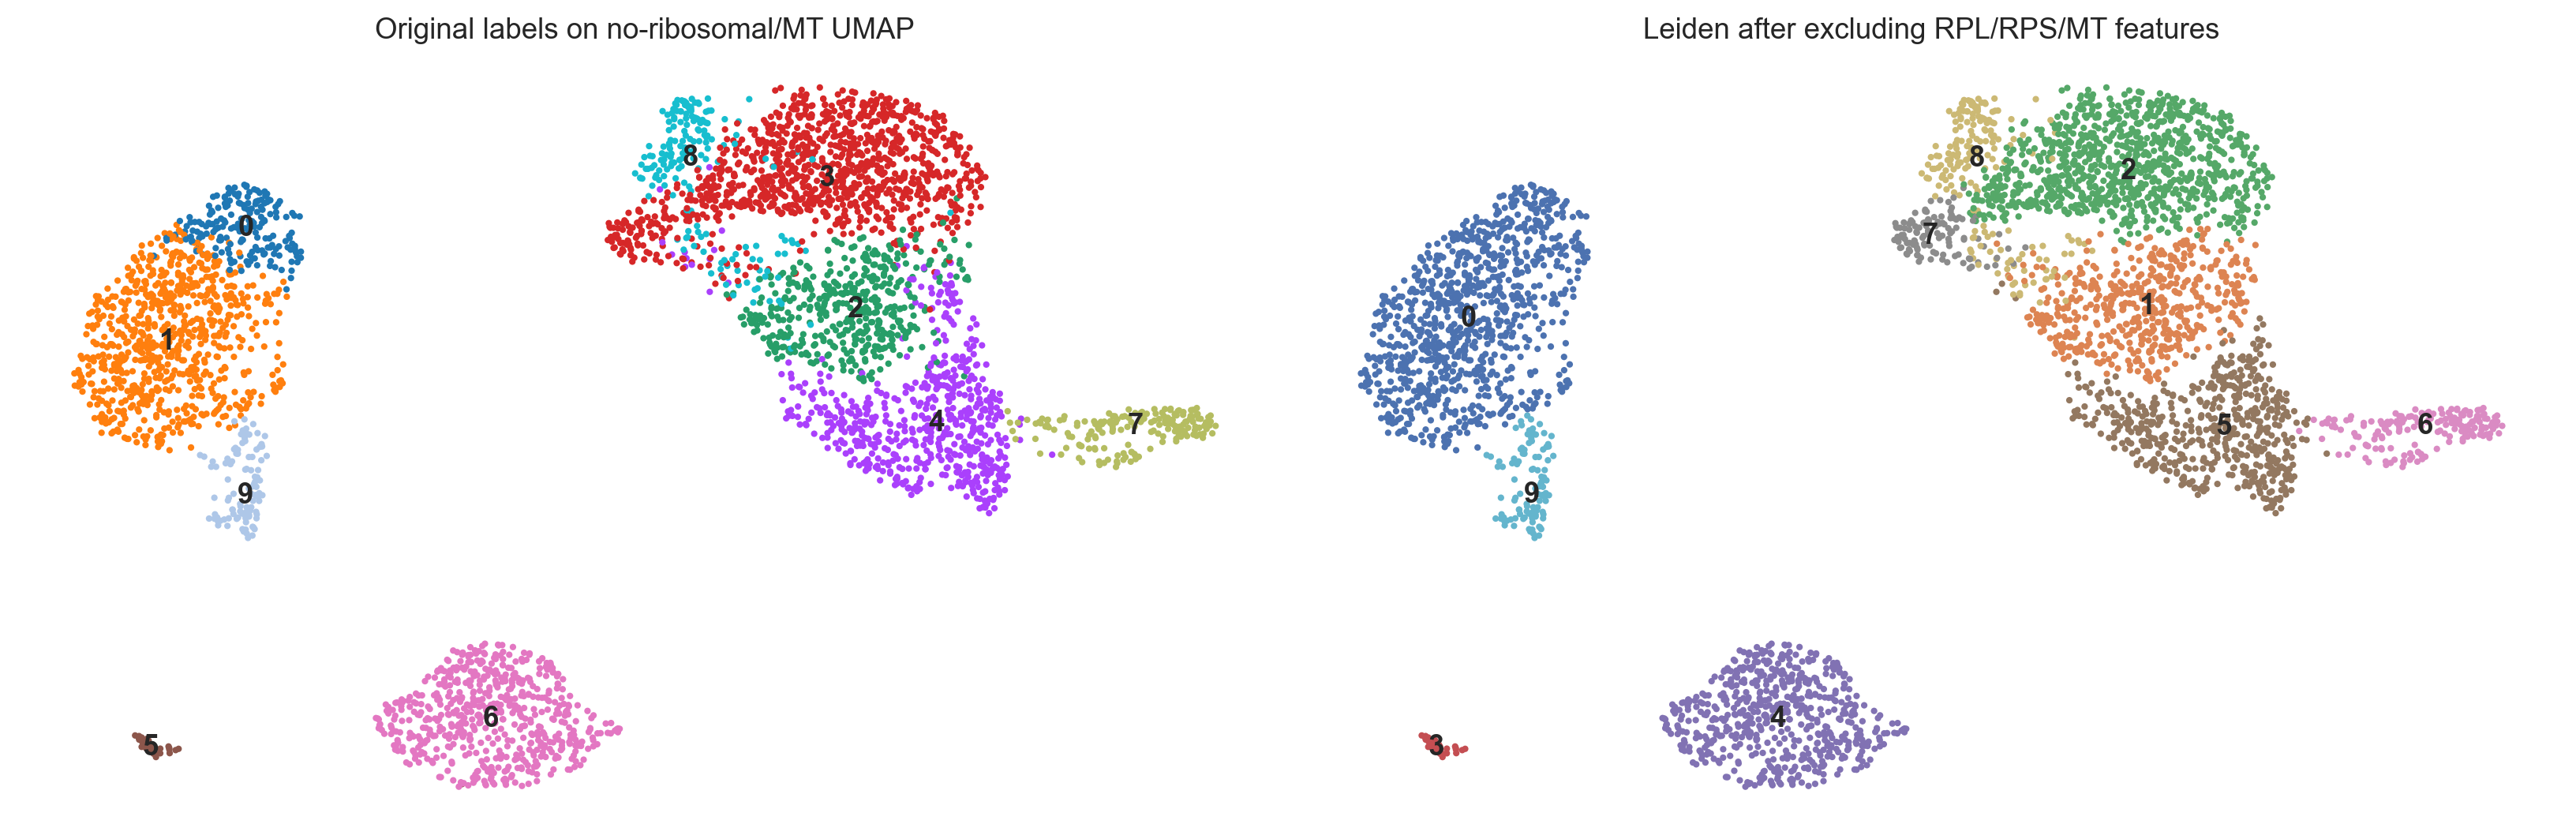

In [9]:
sensitivity_mapping = pd.crosstab(
    primary_labels,
    sensitivity_labels,
    rownames=["primary_leiden"],
    colnames=["no_ribo_mt_leiden"],
)
sensitivity_mapping.to_csv(TABLES / "pbmc4k_phase3_no_ribo_mt_cluster_mapping.csv")
display(sensitivity_mapping)

focus_rows = []
for original_cluster in ("3", "8"):
    mask = primary_labels.to_numpy() == original_cluster
    destination_counts = sensitivity_labels[mask].value_counts()
    destination = str(destination_counts.index[0])
    overlap = int(destination_counts.iloc[0])
    destination_size = int((sensitivity_labels == destination).sum())
    focus_rows.append(
        {
            "original_cluster": original_cluster,
            "original_cells": int(mask.sum()),
            "dominant_no_ribo_mt_cluster": destination,
            "cells_in_dominant_destination": overlap,
            "cohesion": overlap / mask.sum(),
            "destination_cluster_cells": destination_size,
            "exclusivity": overlap / destination_size,
        }
    )
cluster_3_8_sensitivity = pd.DataFrame(focus_rows).set_index("original_cluster")
cluster_3_8_sensitivity.to_csv(TABLES / "pbmc4k_phase3_cluster_3_8_no_ribo_mt_review.csv")
display(
    cluster_3_8_sensitivity.style.format({"cohesion": "{:.1%}", "exclusivity": "{:.1%}"})
)

same_destination = (
    cluster_3_8_sensitivity.loc["3", "dominant_no_ribo_mt_cluster"]
    == cluster_3_8_sensitivity.loc["8", "dominant_no_ribo_mt_cluster"]
)
print("Clusters 3 and 8 share the same dominant no-ribosomal/MT destination:", same_destination)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sc.pl.umap(
    sensitivity,
    color="original_leiden",
    legend_loc="on data",
    title="Original labels on no-ribosomal/MT UMAP",
    ax=axes[0],
    show=False,
)
sc.pl.umap(
    sensitivity,
    color="leiden_no_ribo_mt",
    legend_loc="on data",
    title="Leiden after excluding RPL/RPS/MT features",
    ax=axes[1],
    show=False,
)
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase3_no_ribo_mt_sensitivity_umap.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Human-review checklist

Before editing the table below, verify:

- multiple related genes support the proposed lineage;
- markers are prevalent inside the cluster and less common outside it;
- the proposed label agrees with the dot plot, ranked markers, and UMAP;
- technical or state-related genes are not mistaken for lineage markers;
- conflicting lineages do not suggest remaining doublets;
- pDC interpretation uses the data-derived pDC genes missing from the shared panel;
- uncertainty is recorded rather than hidden.

## 8. EDIT THIS CELL: annotation decisions

In the next code cell, replace every `REVIEW_REQUIRED` value with a reviewed cell type and confidence. Valid confidence values are `high`, `moderate`, or `low`. Add concise marker evidence in `evidence_notes`.

Do not edit the generated marker CSV files; rerunning the notebooks can overwrite them.

In [10]:
# EDIT ONLY THE VALUES IN THIS DICTIONARY AFTER REVIEWING THE EVIDENCE ABOVE.
annotation_decisions = {
    "0": {"cell_type": "Classical monocytes", "confidence": "High", "evidence_notes": "LYZ, S100A8, S100A9, S100A12, FCN1, CTSS, TYROBP and LST1 support an S100-high classical-monocyte program"},
    "1": {"cell_type": "Classical monocytes", "confidence": "High", "evidence_notes": "LYZ, FCN1, S100A8, S100A9, CTSS, TYROBP, CSTA, MNDA and LST1 support classical-monocyte identity; higher RNA complexity distinguishes this state from cluster 0"},
    "2": {"cell_type": "IL7R+ memory/helper T cells", "confidence": "High", "evidence_notes": "CD3D, CD3E and TRAC establish T-cell identity; IL7R, LTB, AQP3, ITGB1 and CD2 support an IL7R-positive memory/helper program"},
    "3": {"cell_type": "Activated/transitional T cells", "confidence": "moderate", "evidence_notes": "CD3D, CD3E, TRAC and LTB establish T-cell identity; FOS, JUN, JUNB, DUSP1, CD69, FOSB and SOCS3 support an immediate activation/stress-response state. After excluding RPL/RPS/MT features, 930 of 1,075 cells remained together and formed 98.9% of their destination cluster, supporting a distinct community rather than a ribosomal artifact"},
    "4": {"cell_type": "Cytotoxic CD8 T cells", "confidence": "High", "evidence_notes": "CD3D and CD3E establish T-cell identity; CCL5, NKG7, GZMA, GZMK, CTSW, CST7, CD8A and CD8B support a cytotoxic CD8 T-cell program"},
    "5": {"cell_type": "Dendritic cells", "confidence": "High", "evidence_notes": "LILRA4, JCHAIN, IRF7, PLD4, GZMB, IRF8 and ITM2C support a rare plasmacytoid dendritic population; the cluster remains intact after doublet removal and no-ribosomal/MT sensitivity analysis"},
    "6": {"cell_type": "B cells", "confidence": "High", "evidence_notes": "CD79A, CD79B, MS4A1, CD74, CD37, HLA-DRA, HLA-DPA1, IGHM and IGHD support a coherent B-cell program"},
    "7": {"cell_type": "NK cells", "confidence": "High", "evidence_notes": "NKG7, GNLY, KLRD1, KLRF1, PRF1, GZMB, CTSW and HOPX support a strong natural-killer cytotoxic program with comparatively weak T-cell receptor expression"},
    "8": {"cell_type": "Naive/resting T cells", "confidence": "Moderate", "evidence_notes": "CD3D, CD3E and TRAC establish T-cell identity; CCR7, MAL, IL7R, LTB and GIMAP7 support a naive/resting program with less FOS/JUN activation than cluster 3. After excluding RPL/RPS/MT features, 179 of 192 cells remained together in a destination separate from cluster 3, supporting an independent community"},
    "9": {"cell_type": "CD16+ non-classical monocytes", "confidence": "High", "evidence_notes": "FCGR3A, LST1, FCER1G, MS4A7, SERPINA1, LILRB1, AIF1, CTSS and IFITM3 support a CD16-positive non-classical-monocyte program"},
}

observed_clusters = [str(cluster) for cluster in cluster_names]
if set(annotation_decisions) != set(observed_clusters):
    raise ValueError("Annotation-decision keys must exactly match the observed Leiden clusters.")

# Reload generated evidence after a kernel restart if the earlier display
# variables are not currently in memory.
if "cluster_marker_summary" not in globals():
    marker_summary_path = TABLES / "pbmc4k_phase3_marker_summary.csv"
    if not marker_summary_path.is_file():
        raise RuntimeError("Run Sections 1–5 before editing and running Section 8.")
    cluster_marker_summary = pd.read_csv(marker_summary_path, index_col="group")
    cluster_marker_summary.index = cluster_marker_summary.index.astype(str)

if "reference_suggestions" not in globals():
    reference_suggestions_path = TABLES / "pbmc4k_phase3_reference_suggestions.csv"
    if reference_suggestions_path.is_file():
        reference_suggestions = pd.read_csv(reference_suggestions_path, index_col=0)
        reference_suggestions.index = reference_suggestions.index.astype(str)
    else:
        marker_overlap = sc.tl.marker_gene_overlap(
            adata,
            reference_markers=available_pbmc_markers,
            key=RANK_KEY,
            method="overlap_count",
            normalize="reference",
            top_n_markers=100,
            inplace=False,
        )
        reference_suggestions = pd.concat(
            [
                marker_overlap.idxmax(axis=0).rename("best_reference_program"),
                marker_overlap.max(axis=0).rename("best_reference_overlap"),
            ],
            axis=1,
        )
        reference_suggestions.index = reference_suggestions.index.astype(str)
        reference_suggestions.to_csv(reference_suggestions_path)

annotation_review = pd.DataFrame.from_dict(annotation_decisions, orient="index")
annotation_review.index.name = "leiden"
annotation_review["confidence"] = annotation_review["confidence"].str.strip().str.lower()
annotation_review["cell_count"] = cluster_sizes["cells"].reindex(cluster_names).to_numpy()
annotation_review["top_filtered_markers"] = cluster_marker_summary[
    "top_filtered_markers"
].reindex(observed_clusters)
annotation_review["best_reference_program"] = reference_suggestions[
    "best_reference_program"
].reindex(observed_clusters)
annotation_review["best_reference_overlap"] = reference_suggestions[
    "best_reference_overlap"
].reindex(observed_clusters)
display(annotation_review.style.format({"best_reference_overlap": "{:.2f}"}))

,cell_type,confidence,evidence_notes,cell_count,top_filtered_markers,best_reference_program,best_reference_overlap
leiden,,,,,,,
0,Classical monocytes,high,"LYZ, S100A8, S100A9, S100A12, FCN1, CTSS, TYROBP and LST1 support an S100-high classical-monocyte program",188,"RP11-1143G9.4, S100A8, LYZ, FTL, S100A9, FTH1, S100A6, CTSS, TYROBP, S100A12, MNDA, GPX1, LST1, MT-CO2, CST3",CD14 monocyte,1.00
1,Classical monocytes,high,"LYZ, FCN1, S100A8, S100A9, CTSS, TYROBP, CSTA, MNDA and LST1 support classical-monocyte identity; higher RNA complexity distinguishes this state from cluster 0",735,"LYZ, CST3, S100A9, FCN1, GPX1, S100A8, S100A6, TYROBP, CSTA, RP11-1143G9.4, CTSS, FTL, LGALS1, MNDA, LST1",CD14 monocyte,1.00
2,IL7R+ memory/helper T cells,high,"CD3D, CD3E and TRAC establish T-cell identity; IL7R, LTB, AQP3, ITGB1 and CD2 support an IL7R-positive memory/helper program",440,"IL32, LTB, IL7R, TRAC, LDHB, ITGB1, CD2, CD3D, HSPA8, HLA-A, AQP3, GSTK1, CRIP1, ANXA1, TRADD",Naive/helper T,0.86
3,Activated/transitional T cells,moderate,"CD3D, CD3E, TRAC and LTB establish T-cell identity; FOS, JUN, JUNB, DUSP1, CD69, FOSB and SOCS3 support an immediate activation/stress-response state. After excluding RPL/RPS/MT features, 930 of 1,075 cells remained together and formed 98.9% of their destination cluster, supporting a distinct community rather than a ribosomal artifact",1075,"RPL32, RPS6, RPL21, RPL31, RPS14, RPL34, RPS3A, RPS15A, RPL35A, RPS25, RPS13, RPS27, RPS12, RPL3, RPS27A",Naive/helper T,0.71
4,Cytotoxic CD8 T cells,high,"CD3D and CD3E establish T-cell identity; CCL5, NKG7, GZMA, GZMK, CTSW, CST7, CD8A and CD8B support a cytotoxic CD8 T-cell program",588,"CCL5, IL32, HLA-B, NKG7, B2M, HLA-C, GZMA, CST7, HLA-A, CTSW, LYAR, GZMK, CD3D, TRGC2, HCST",Cytotoxic T,1.00
5,Dendritic cells,high,"LILRA4, JCHAIN, IRF7, PLD4, GZMB, IRF8 and ITM2C support a rare plasmacytoid dendritic population; the cluster remains intact after doublet removal and no-ribosomal/MT sensitivity analysis",34,"SEC61B, LILRA4, IRF7, PLD4, JCHAIN, IRF8, ITM2C, C12orf75, LRRC26, ALOX5AP, PLAC8, PPP1R14B, CCDC50, MZB1, TXN",Dendritic,0.25
6,B cells,high,"CD79A, CD79B, MS4A1, CD74, CD37, HLA-DRA, HLA-DPA1, IGHM and IGHD support a coherent B-cell program",592,"CD79A, CD74, CD79B, MS4A1, CD37, HLA-DPA1, HLA-DQB1, HLA-DRA, HLA-DPB1, IGHM, HLA-DRB1, IGHD, HLA-DQA1, BANK1, HLA-DMA",B,1.00
7,NK cells,high,"NKG7, GNLY, KLRD1, KLRF1, PRF1, GZMB, CTSW and HOPX support a strong natural-killer cytotoxic program with comparatively weak T-cell receptor expression",181,"NKG7, GNLY, CTSW, HOPX, KLRF1, PRF1, KLRD1, GZMA, CST7, GZMB, HLA-C, HLA-B, HLA-A, CD7, B2M",NK,1.00
8,Naive/resting T cells,moderate,"CD3D, CD3E and TRAC establish T-cell identity; CCR7, MAL, IL7R, LTB and GIMAP7 support a naive/resting program with less FOS/JUN activation than cluster 3. After excluding RPL/RPS/MT features, 179 of 192 cells remained together in a destination separate from cluster 3, supporting an independent community",192,"RPS14, RPS6, RPS12, RPL32, RPS27, MALAT1, RPL31, RPS15A, RPL30, RPS25, RPS29, RPL11, LDHB, RPS3, RPL3",Naive/helper T,1.00


## 9. Validate and apply completed decisions

This safety gate does not apply partial annotations.

In [11]:
review_complete = not annotation_review[["cell_type", "confidence"]].eq("REVIEW_REQUIRED").any().any()
valid_confidence = annotation_review["confidence"].isin(["high", "moderate", "low"]).all()
evidence_complete = annotation_review["evidence_notes"].str.strip().ne("").all()

if not review_complete:
    print("Annotations not applied: replace every REVIEW_REQUIRED value in Section 8.")
elif not valid_confidence:
    print("Annotations not applied: confidence must be high, moderate, or low.")
elif not evidence_complete:
    print("Annotations not applied: add marker evidence for every cluster.")
else:
    cluster_to_cell_type = annotation_review["cell_type"].to_dict()
    cluster_to_confidence = annotation_review["confidence"].to_dict()
    leiden_strings = adata.obs["leiden"].astype(str)
    adata.obs["cell_type"] = leiden_strings.map(cluster_to_cell_type).astype("category")
    adata.obs["annotation_confidence"] = (
        leiden_strings.map(cluster_to_confidence).astype("category")
    )
    print("Applied reviewed PBMC4k labels to every singlet.")
    display(pd.crosstab(adata.obs["leiden"], adata.obs["cell_type"]))

Applied reviewed PBMC4k labels to every singlet.


cell_type,Activated/transitional T cells,B cells,CD16+ non-classical monocytes,Classical monocytes,Cytotoxic CD8 T cells,Dendritic cells,IL7R+ memory/helper T cells,NK cells,Naive/resting T cells
leiden,,,,,,,,,
0,0,0,0,188,0,0,0,0,0
1,0,0,0,735,0,0,0,0,0
2,0,0,0,0,0,0,440,0,0
3,1075,0,0,0,0,0,0,0,0
4,0,0,0,0,588,0,0,0,0
5,0,0,0,0,0,34,0,0,0
6,0,592,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,181,0
8,0,0,0,0,0,0,0,0,192


## 10. Visual validation

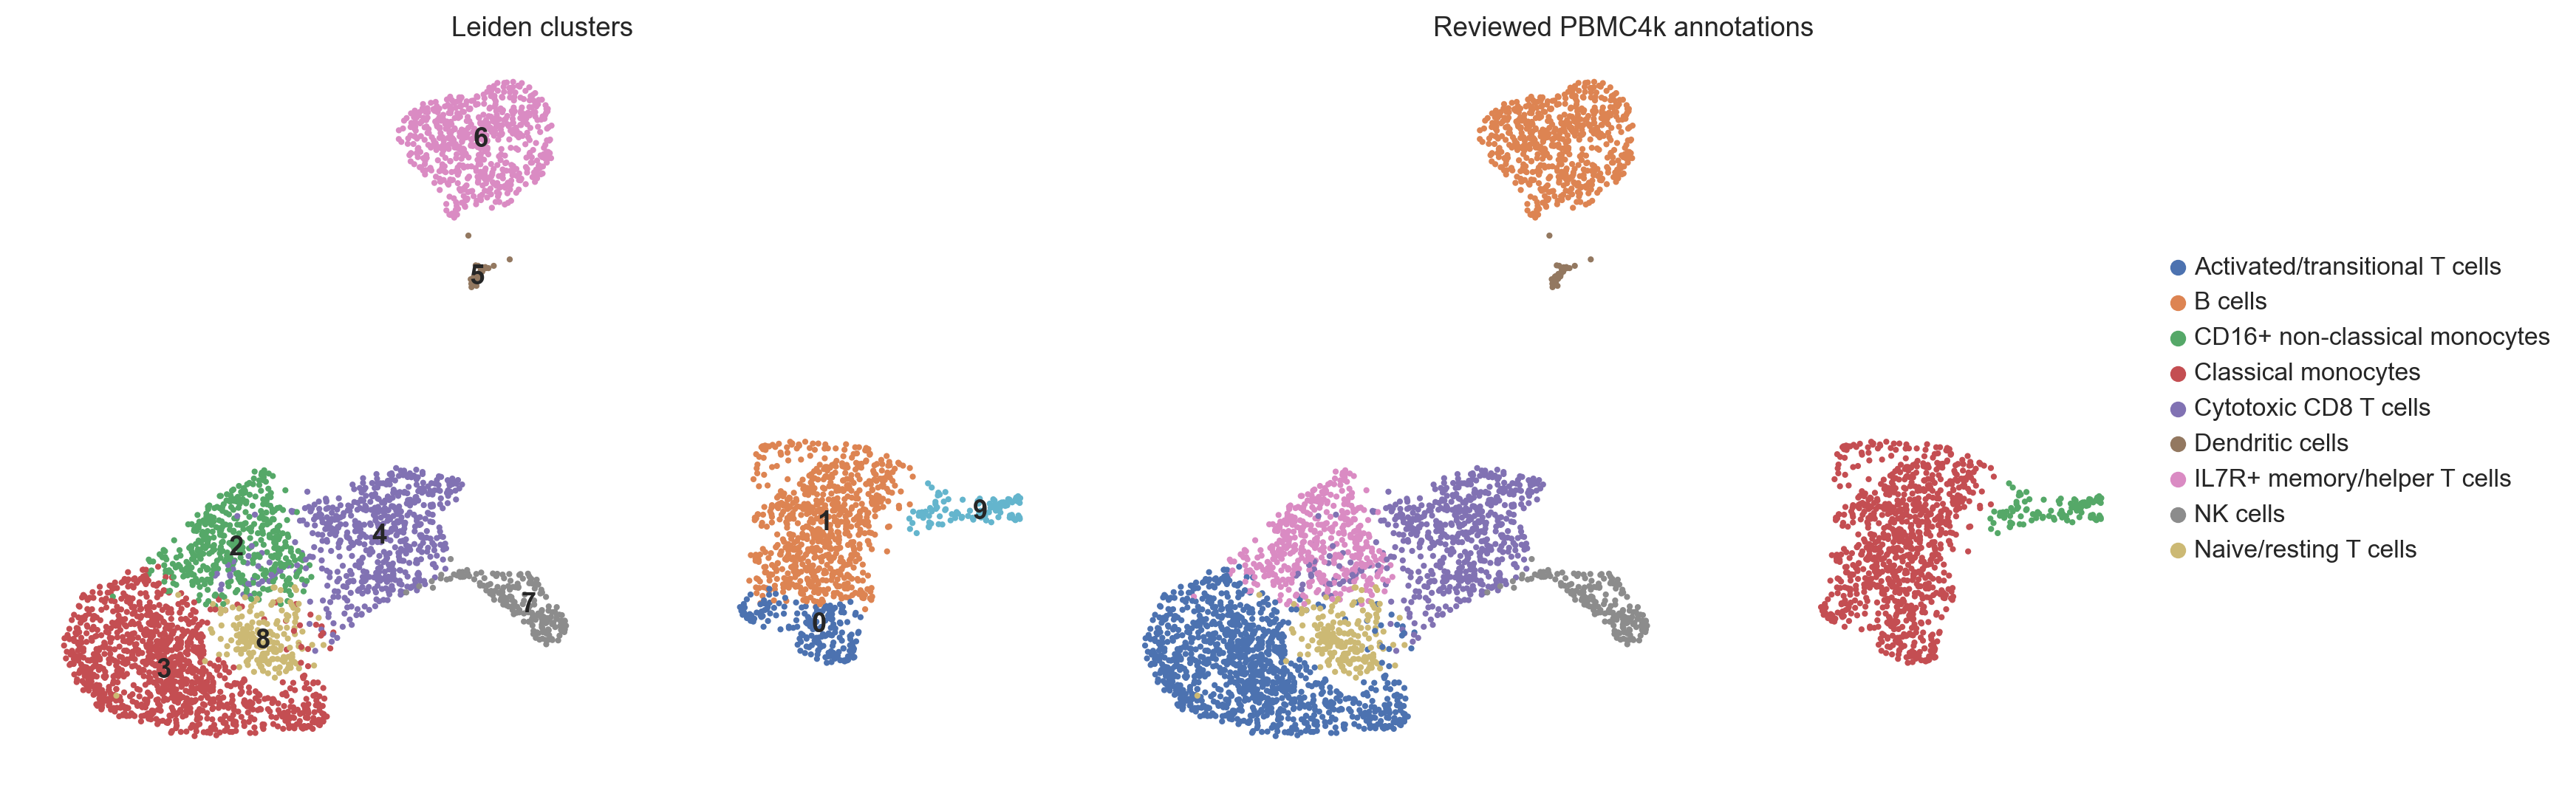

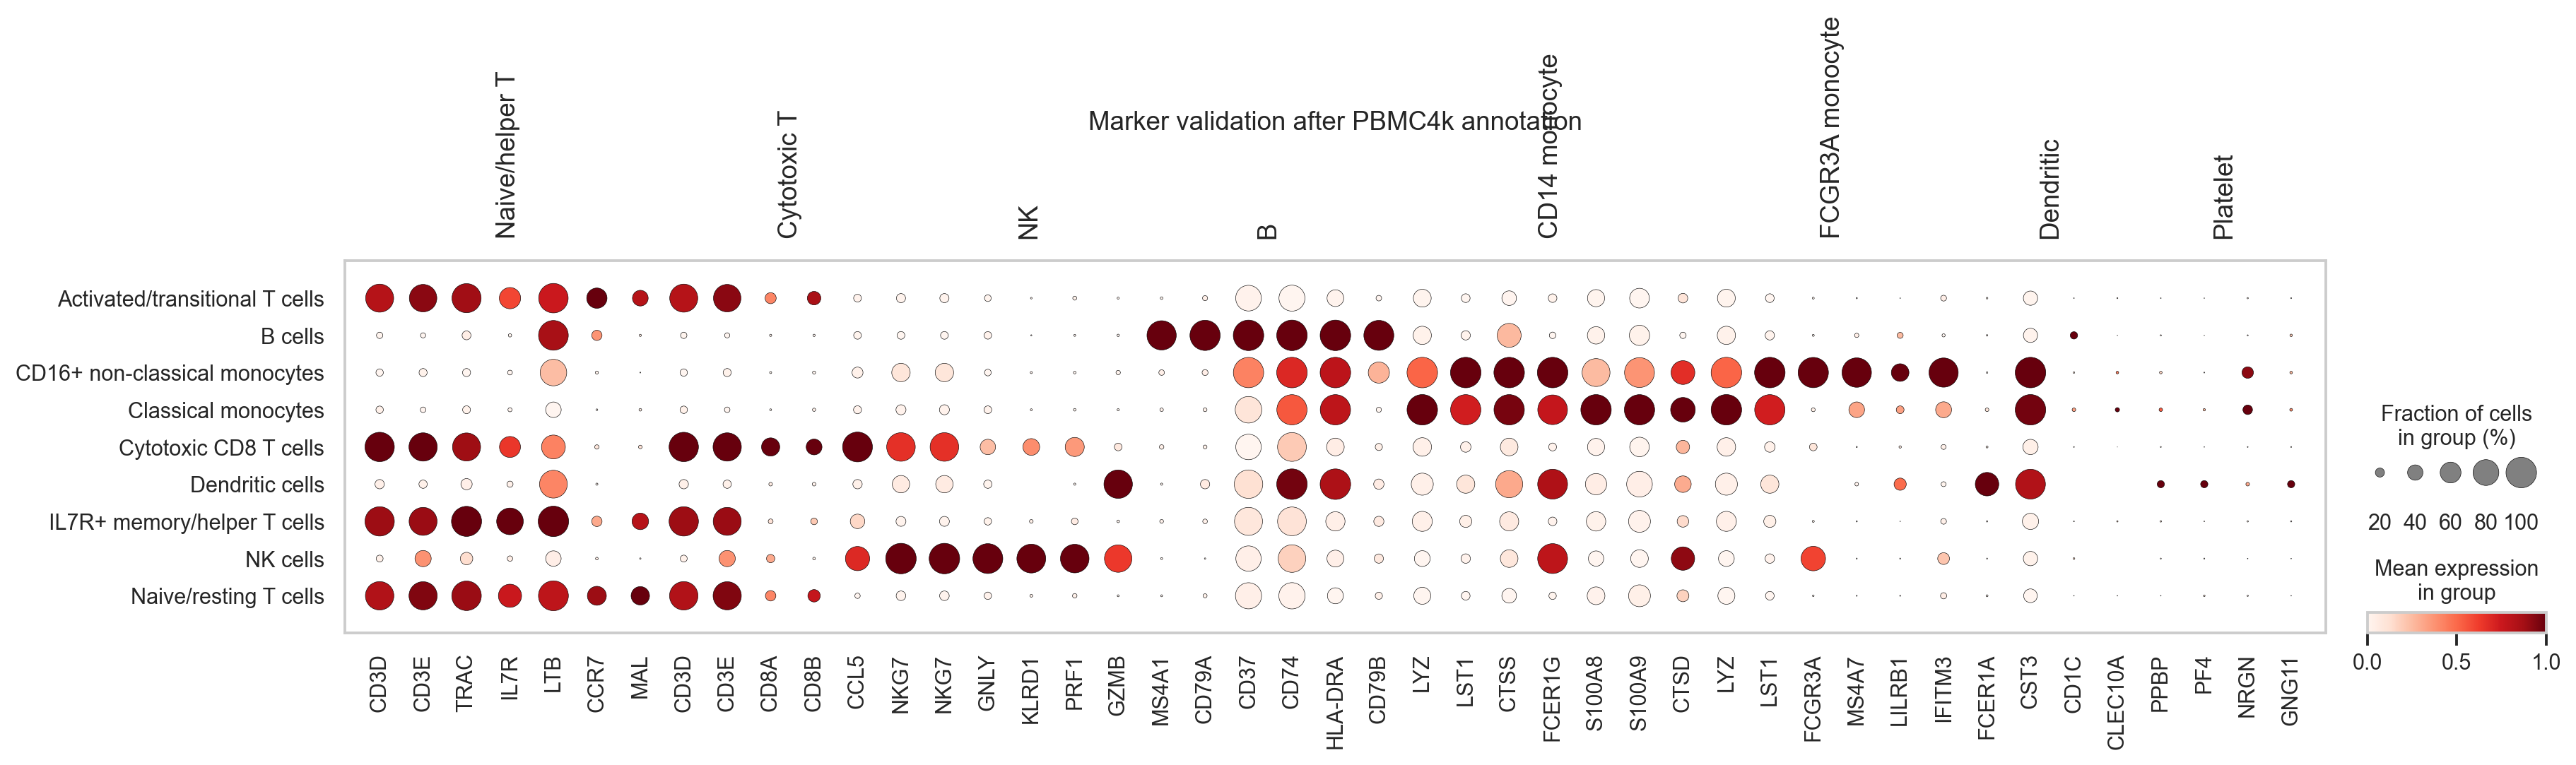

In [12]:
if "cell_type" not in adata.obs:
    print("Complete and apply the Section 8 review before visual validation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sc.pl.umap(
        adata,
        color="leiden",
        legend_loc="on data",
        title="Leiden clusters",
        ax=axes[0],
        show=False,
    )
    sc.pl.umap(
        adata,
        color="cell_type",
        legend_loc="right margin",
        title="Reviewed PBMC4k annotations",
        ax=axes[1],
        show=False,
    )
    plt.tight_layout()
    plt.savefig(FIGURES / "pbmc4k_phase3_reviewed_annotations_umap.png", dpi=160, bbox_inches="tight")
    plt.show()

    sc.pl.dotplot(
        adata,
        available_pbmc_markers,
        groupby="cell_type",
        use_raw=True,
        standard_scale="var",
        title="Marker validation after PBMC4k annotation",
        show=False,
    )
    plt.savefig(FIGURES / "pbmc4k_phase3_annotation_marker_validation.png", dpi=160, bbox_inches="tight")
    plt.show()

## 11. Save only a completed annotation review

In [13]:
if "cell_type" not in adata.obs:
    print("Nothing saved: complete, apply, and visually validate the annotation review first.")
else:
    annotation_path = TABLES / "pbmc4k_phase3_cell_type_annotations.csv"
    annotation_review.to_csv(annotation_path)
    adata.uns["cell_type_annotation"] = {
        "source_cluster_column": "leiden",
        "expected_clusters": N_EXPECTED_CLUSTERS,
        "method": "human review of Wilcoxon markers, prevalence, UMAP, and unchanged PBMC3k marker programs",
        "rank_genes_groups_key": RANK_KEY,
        "independent_ground_truth": False,
    }
    adata.write_h5ad(OUTPUT, compression="gzip")
    print("Saved annotation decisions:", annotation_path)
    print("Saved annotated object:", OUTPUT)
    print(f"Output size: {OUTPUT.stat().st_size / 1024**2:.1f} MB")

Saved annotation decisions: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/results/tables/pbmc4k_phase3_cell_type_annotations.csv
Saved annotated object: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/processed/pbmc4k_phase3_annotated.h5ad
Output size: 63.3 MB
